# Agent Graph Visualization

This notebook visualizes the directed graphs of **both agents**:
1. **Data Curation Agent** - Continuous monitoring and dataset readiness
2. **Causal Discovery Agent** - On-demand causal analysis

Both agents use LangGraph and are visualized using Mermaid diagrams.


In [1]:
# Import required libraries
import sys
import os
from pathlib import Path
from IPython.display import Image, display, Markdown

# Add the cryptosentinel directory to the path
project_root = Path.cwd()
cryptosentinel_path = project_root / "cryptosentinel"
if str(cryptosentinel_path) not in sys.path:
    sys.path.insert(0, str(cryptosentinel_path))

print(f"Project root: {project_root}")
print(f"CryptoSentinel path: {cryptosentinel_path}")
print(f"Python path includes: {cryptosentinel_path.exists()}")


Project root: /Users/khoadangnguyen/Desktop/confluent_ai_catalyst/cryptosentinel
CryptoSentinel path: /Users/khoadangnguyen/Desktop/confluent_ai_catalyst/cryptosentinel/cryptosentinel
Python path includes: False


In [2]:
# Import both agents
from agent.orchestrator import CausalDiscoveryAgent
from agent.curation_orchestrator import DataCurationAgent
from config.settings import get_settings

settings = get_settings()

print("✅ Successfully imported CausalDiscoveryAgent")
print("✅ Successfully imported DataCurationAgent")


✅ Successfully imported CausalDiscoveryAgent
✅ Successfully imported DataCurationAgent


In [3]:
# Initialize BOTH agents
print("📦 Initializing agents...")

import dotenv
from pathlib import Path

env_path = Path('.') / '.env'
if env_path.exists():
    print("✅ .env file found at project root.")
else:
    print("⚠️  .env file not found at project root - attempting to load environment variables anyway.")

# Attempt to load the .env file if present to make environment variables available
dotenv.load_dotenv(dotenv_path=env_path, override=True)

from config.settings import Settings

# Now try to get settings using the actual get_settings() function
try:
    from config.settings import get_settings
    settings = get_settings()
    print("✅ Loaded settings from get_settings (using env/ENV vars)")
except Exception as e:
    print(f"⚠️  get_settings() failed: {e}")
    print("   Attempting to construct Settings manually from environment variables...")

    # Construct Settings from environment variables directly
    settings = Settings(
        kafka_bootstrap_servers=os.getenv("KAFKA_BOOTSTRAP_SERVERS", ""),
        kafka_api_key=os.getenv("KAFKA_API_KEY", ""),
        kafka_api_secret=os.getenv("KAFKA_API_SECRET", ""),
        schema_registry_url=os.getenv("SCHEMA_REGISTRY_URL", ""),
        schema_registry_api_key=os.getenv("SCHEMA_REGISTRY_API_KEY", ""),
        schema_registry_api_secret=os.getenv("SCHEMA_REGISTRY_API_SECRET", ""),
        gemini_api_key=os.getenv("GEMINI_API_KEY", ""),
        reddit_client_id=os.getenv("REDDIT_CLIENT_ID", ""),
        reddit_client_secret=os.getenv("REDDIT_CLIENT_SECRET", ""),
    )
    print("✅ Created mock settings from os.environ for visualization")

# Initialize Causal Discovery Agent
try:
    causal_agent = CausalDiscoveryAgent(settings)
    print("✅ Causal Discovery Agent initialized successfully!")
    print(f"   Graph available: {causal_agent.graph is not None}")
    print(f"   App compiled: {causal_agent.app is not None}")
except Exception as e:
    print(f"❌ Error initializing causal agent: {e}")
    import traceback
    traceback.print_exc()
    causal_agent = None

# Initialize Data Curation Agent
try:
    curation_agent = DataCurationAgent(settings)
    print("✅ Data Curation Agent initialized successfully!")
    print(f"   Graph available: {curation_agent.graph is not None}")
    print(f"   App compiled: {curation_agent.app is not None}")
except Exception as e:
    print(f"❌ Error initializing curation agent: {e}")
    import traceback
    traceback.print_exc()
    curation_agent = None


📦 Initializing agents...
✅ .env file found at project root.
✅ Loaded settings from get_settings (using env/ENV vars)


2025-12-30 15:20:38.482 | INFO     | agent.hypothesis_generator:__init__:261 - Vertex AI will use service-account credentials from GOOGLE_APPLICATION_CREDENTIALS (/Users/khoadangnguyen/Desktop/confluent_ai_catalyst/cryptosentinel/gcp-service-account-key.json)
/Users/khoadangnguyen/Desktop/confluent_ai_catalyst/cryptosentinel/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()
2025-12-30 15:20:38.487 | INFO     | agent.hypothesis_generator:__init__:276 - HypothesisGenerator initialized with Vertex AI (project=gen-lang-client-0603506236, region=us-central1, model=gemini-2.0-flash-001)
2025-12-30 15:20:38.548 | INFO     | agent.hypothesis_generator:__init__:286 - HypothesisGenerator AI Studio client ready (model=g

✅ Causal Discovery Agent initialized successfully!
   Graph available: True
   App compiled: True
✅ Data Curation Agent initialized successfully!
   Graph available: True
   App compiled: True


🔬 CAUSAL DISCOVERY AGENT GRAPH
✅ Retrieved Causal Discovery graph from compiled app


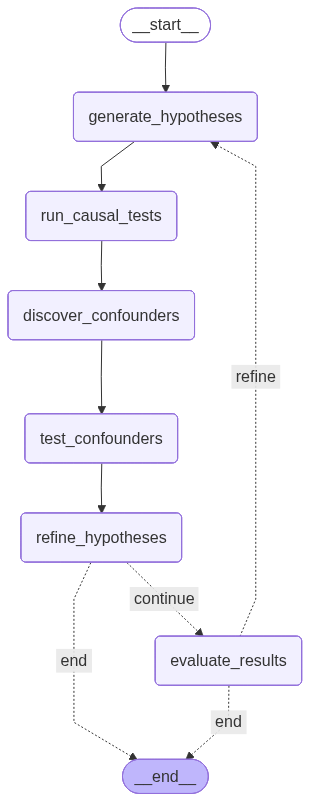

✅ Displayed Causal Discovery graph using draw_mermaid_png()


📊 DATA CURATION AGENT GRAPH
✅ Retrieved Data Curation graph from compiled app


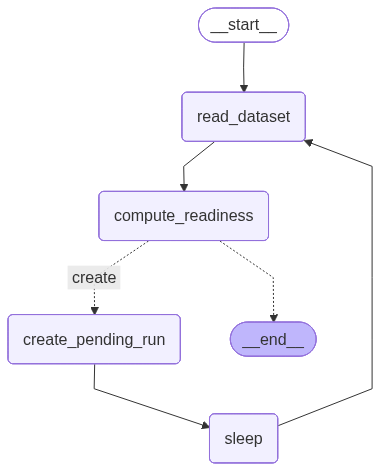

✅ Displayed Data Curation graph using draw_mermaid_png()


In [4]:
def visualize_graph(agent, agent_name):
    """Visualize a LangGraph agent."""
    if agent is None or agent.graph is None:
        print(f"⚠️  {agent_name} graph is None - LangGraph may not be available or graph not built")
        return
    
    try:
        # Get the graph object
        if agent.app is not None:
            try:
                graph_obj = agent.app.get_graph()
                print(f"✅ Retrieved {agent_name} graph from compiled app")
            except AttributeError:
                graph_obj = agent.graph
                print(f"✅ Using {agent_name} graph directly")
        else:
            graph_obj = agent.graph
            print(f"✅ Using {agent_name} graph directly (app not compiled)")
        
        # Generate mermaid visualization
        try:
            mermaid_png = graph_obj.draw_mermaid_png()
            display(Image(mermaid_png))
            print(f"✅ Displayed {agent_name} graph using draw_mermaid_png()")
        except AttributeError:
            try:
                mermaid_str = graph_obj.draw_mermaid()
                display(Markdown(f"```mermaid\n{mermaid_str}\n```"))
                print(f"✅ Displayed {agent_name} graph using draw_mermaid()")
            except AttributeError:
                try:
                    if hasattr(graph_obj, 'get_graph'):
                        inner_graph = graph_obj.get_graph()
                        mermaid_png = inner_graph.draw_mermaid_png()
                        display(Image(mermaid_png))
                        print(f"✅ Displayed {agent_name} graph using get_graph().draw_mermaid_png()")
                    else:
                        raise AttributeError("No get_graph method")
                except (AttributeError, Exception) as e:
                    print(f"⚠️  Could not visualize {agent_name} graph: {e}")
                    print(f"   Graph type: {type(graph_obj)}")
                    print(f"   Graph methods: {[m for m in dir(graph_obj) if not m.startswith('_')]}")
                    
    except Exception as e:
        print(f"❌ Error visualizing {agent_name} graph: {e}")
        import traceback
        traceback.print_exc()

# Visualize Causal Discovery Agent
print("=" * 70)
print("🔬 CAUSAL DISCOVERY AGENT GRAPH")
print("=" * 70)
visualize_graph(causal_agent, "Causal Discovery")

print("\n")

# Visualize Data Curation Agent
print("=" * 70)
print("📊 DATA CURATION AGENT GRAPH")
print("=" * 70)
visualize_graph(curation_agent, "Data Curation")
